### Data Preprocessing And Feature Engineering In Machine Learning

#### Tasks:
##### 1.	Handle missing values as per the best practices (imputation, removal, etc.).

●	Apply scaling techniques to numerical features:

a.	Standard Scaling      b. Min-Max Scaling

●	Discuss the scenarios where each scaling technique is preferred and why.

##### 2. Encoding Techniques:

●	Apply One-Hot Encoding to categorical variables with less than 5 categories.

●	Use Label Encoding for categorical variables. 
                      
Data Exploration and Preprocessing:

●	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).

●	les with more than 5 categories.

●	Discuss the pros and cons of One-Hot Encoding and Label Encoding.

##### 3. Feature Engineering:

●	Create at least 2 new features that could be beneficial for the model. Explain the  rationale behind your choices.

●	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.



In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Load Dataset
df = pd.read_csv("adult_with_headers.csv")

In [30]:
# No of rows & columns
df.shape

(32561, 15)

In [31]:
# First 5 rows of dataset
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [32]:
target="income"

In [33]:
# Statistical summary
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [34]:
# Check missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [35]:
# Check datatypes of each column
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [36]:
# Handle Missing Values
# Fill numerical missing values with median, categorical with mode

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="most_frequent")

df[num_cols] = imputer_num.fit_transform(df[num_cols])
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [37]:
# Scaling Numerical Features
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# scaling on "age" feature
df["age_standard"] = scaler_standard.fit_transform(df[["age"]])
df["age_minmax"] = scaler_minmax.fit_transform(df[["age"]])

* Standard Scaling -> preferred when data follows Gaussian distribution (mean=0, std=1)

* Min-Max Scaling -> preferred when values must be in a fixed range [0,1], sensitive to outliers


In [38]:
# Encoding Categorical Variables
encoded_df = df.copy()

In [39]:
# One-Hot Encoding for categorical vars with < 5 categories
low_cardinality = [col for col in cat_cols if df[col].nunique() < 5]
encoded_df = pd.get_dummies(encoded_df, columns=low_cardinality, drop_first=True)

In [40]:
# Label Encoding for other categorical vars
high_cardinality = [col for col in cat_cols if df[col].nunique() >= 5]
le = LabelEncoder()
for col in high_cardinality:
    encoded_df[col] = le.fit_transform(encoded_df[col])

* One-Hot Encoding -> avoids ordinal assumption, good for low-cardinality categorical vars, but increases dimensionality if categories are many
  
* Label Encoding -> efficient, but imposes ordinal relationships which may mislead models

In [41]:
print("\nEncoded Data Sample:") 
encoded_df.head()


Encoded Data Sample:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,age_standard,age_minmax,sex_ Male,income_ >50K
0,39.0,7,77516.0,9,13.0,4,1,1,4,2174.0,0.0,40.0,39,0.030671,0.301370,True,False
1,50.0,6,83311.0,9,13.0,2,4,0,4,0.0,0.0,13.0,39,0.837109,0.452055,True,False
2,38.0,4,215646.0,11,9.0,0,6,1,4,0.0,0.0,40.0,39,-0.042642,0.287671,True,False
3,53.0,4,234721.0,1,7.0,2,6,0,2,0.0,0.0,40.0,39,1.057047,0.493151,True,False
4,28.0,4,338409.0,9,13.0,2,10,5,2,0.0,0.0,40.0,5,-0.775768,0.150685,False,False


In [42]:
# Feature Engineering
# Feature 1: Age Group
encoded_df["age_group"] = pd.cut(df["age"], bins=[0, 25, 45, 65, 100], labels=["Young", "Adult", "Middle_Aged", "Senior"]) 

# Feature 2: Hours-per-week Binned
encoded_df["work_hours_category"] = pd.cut(df["hours_per_week"], bins=[0, 20, 40, 60, 100], labels=["Part-time", "Full-time", "Overtime", "Extreme"])

##### Rationale: 

Age groups and work hours categories may better capture non-linear relationships, with income compared to raw continuous variables.

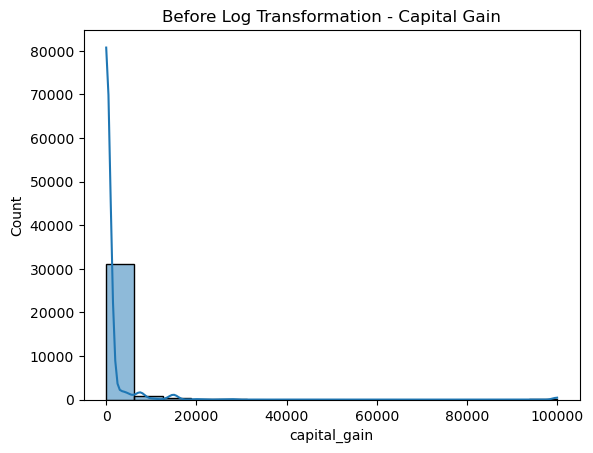

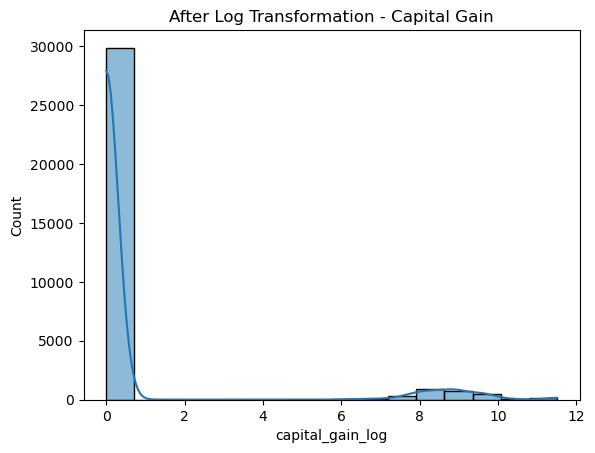

In [43]:
# Transformation on Skewed Numerical Feature 
# log transformation on 'capital-gain' (highly skewed feature) 
sns.histplot(df["capital_gain"], kde=True)
plt.title("Before Log Transformation - Capital Gain") 
plt.show()

encoded_df["capital_gain_log"] = np.log1p(df["capital_gain"]) 
sns.histplot(encoded_df["capital_gain_log"], kde=True) 
plt.title("After Log Transformation - Capital Gain")
plt.show()

##### Rationale:

Log transformation reduces skewness, stabilizes variance, and helps some models perform better

In [44]:
# Isolation Forest (Outlier Detection)
num_cols = df.select_dtypes(include=[np.number]).columns 
iso = IsolationForest(contamination=0.02, random_state=42) 
outlier_flag = iso.fit_predict(df[num_cols])

df["outlier_flag"] = outlier_flag

print("\nOutlier Counts (Isolation Forest):") 
print(df["outlier_flag"].value_counts())


Outlier Counts (Isolation Forest):
outlier_flag
 1    31909
-1      652
Name: count, dtype: int64


In [ ]:
# PPS score analysis (using mutual information)
try:
    from pps.ppscore import PPS
    
except ImportError:
    print("PPS not available. Using Mutual Information instead.")
    
    # Import the missing mutual_info_classif function
    from sklearn.feature_selection import mutual_info_classif
    
    # One-hot encode categorical variables except target
    df_encoded = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
    
    # Encode target if categorical
    if df[target].dtype == 'object':
        y = pd.factorize(df[target])[0]
    else:
        y = df[target].values
    
    # Calculate mutual information
    mi_scores = mutual_info_classif(df_encoded, y, random_state=42)
    
    # Create dataframe with results
    mi_df = pd.DataFrame({
        "Feature": df_encoded.columns,
        "MI Score": mi_scores
    }).sort_values(by="MI Score", ascending=False)
    
    print("\nTop Features by Mutual Information:")
    print(mi_df.head(10))
    
    # Visualization
    plt.figure(figsize=(10, 5))
    sns.barplot(data=mi_df.head(10), x="MI Score", y="Feature", palette="mako")
    plt.title("Top Features by Mutual Information Score",color="green")
    plt.tight_layout()
    plt.show()

PPS not available. Using Mutual Information instead.


In [24]:
# Final Preprocessed Data
print("Final Preprocessed Dataset Shape:\n", encoded_df.shape) 
print(encoded_df.head())

Final Preprocessed Dataset Shape:
 (32561, 20)
    age  workclass    fnlwgt  education  education_num  marital_status  \
0  39.0          7   77516.0          9           13.0               4   
1  50.0          6   83311.0          9           13.0               2   
2  38.0          4  215646.0         11            9.0               0   
3  53.0          4  234721.0          1            7.0               2   
4  28.0          4  338409.0          9           13.0               2   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           1             1     4        2174.0           0.0            40.0   
1           4             0     4           0.0           0.0            13.0   
2           6             1     4           0.0           0.0            40.0   
3           6             0     2           0.0           0.0            40.0   
4          10             5     2           0.0           0.0            40.0   

   native_country  ag

                                                                            Submitted by: Meghana C Varghese